# Modality Selectivity Map

This notebook computes parcel modality selectivity from `parcel_modality_attn_norm.npy`. The normalized modality attention matrix is converted to within-parcel modality probabilities, entropy is computed for each parcel, and selectivity is visualized on the subject Schaefer atlas.


In [67]:
%matplotlib inline

from pathlib import Path
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import nibabel as nib
from nilearn import plotting
import seaborn as sns

warnings.filterwarnings("ignore")

font_dir = "/engram/nklab/pf2477/other/font/"
if os.path.isdir(font_dir):
    for font in os.listdir(font_dir):
        if font.startswith("Times New Roman"):
            fm.fontManager.addfont(os.path.join(font_dir, font))

plt.rcParams["font.family"] = "Times New Roman"
sns.set_theme(style="white", font="Times New Roman")

REPO_ROOT = Path.cwd()
if REPO_ROOT.name != "multimodal_encoder":
    REPO_ROOT = Path("/engram/nklab/pf2477/multimodal_encoder")

RESULT_ROOT = REPO_ROOT / "attn_map_analysis" / "results"
FIGURE_ROOT = REPO_ROOT / "attn_map_analysis" / "figures"
TABLE_ROOT = REPO_ROOT / "attn_map_analysis" / "tables"
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
TABLE_ROOT.mkdir(parents=True, exist_ok=True)

RUNS = (
    (1, "04-07-2026-16-09", "dino_whisper_llama", "parcels"),
    (2, "04-07-2026-16-13", "dino_whisper_llama", "parcels"),
    (3, "04-08-2026-00-52", "dino_whisper_llama", "parcels"),
    (5, "04-08-2026-00-55", "dino_whisper_llama", "parcels"),
    (1, "04-08-2026-23-43", "dino_whisper_llama", "voxels"),
    (2, "04-08-2026-23-48", "dino_whisper_llama", "voxels"),
    (3, "04-08-2026-23-57", "dino_whisper_llama", "voxels"),
    (5, "04-12-2026-19-49", "dino_whisper_llama", "voxels"),
    (1, "04-18-2026-01-08", "videmae_wav2vec_deberta", "parcels"),
    (2, "04-18-2026-01-14", "videmae_wav2vec_deberta", "parcels"),
    (3, "04-18-2026-22-20", "videmae_wav2vec_deberta", "parcels"),
    (5, "04-18-2026-22-22", "videmae_wav2vec_deberta", "parcels"),
    (1, "04-19-2026-02-08", "videmae_wav2vec_deberta", "voxels"),
    (2, "04-19-2026-02-10", "videmae_wav2vec_deberta", "voxels"),
    (3, "04-20-2026-00-29", "videmae_wav2vec_deberta", "voxels"),
    (5, "04-20-2026-00-29", "videmae_wav2vec_deberta", "voxels"),
)

SELECTED_RUN_INDEX = 8
SELECTED_RUN_KEY = None


## Load Selected Run

In [68]:
def load_json(path):
    with Path(path).open("r") as f:
        return json.load(f)


def normalized_entropy(p, axis=-1, eps=1e-12):
    p = np.asarray(p, dtype=np.float64)
    p = p / np.clip(p.sum(axis=axis, keepdims=True), eps, None)
    ent = -(p * np.log(np.clip(p, eps, None))).sum(axis=axis)
    return ent / np.log(p.shape[axis])


def make_run_key(subject_id, run_name, backbones, readout):
    return f"sub-{int(subject_id):02d}_{backbones}_{readout}_{run_name}"


def file_label(run):
    return f"sub-{run['subject_id']:02d}_{run['backbones']}_{run['readout']}_{run['run_name']}"


def selected_run_spec():
    if SELECTED_RUN_KEY is not None:
        for spec in RUNS:
            subject_id, run_name, backbones, readout = spec
            if make_run_key(subject_id, run_name, backbones, readout) == SELECTED_RUN_KEY:
                return spec
        raise KeyError(f"SELECTED_RUN_KEY not found in RUNS: {SELECTED_RUN_KEY}")
    return RUNS[int(SELECTED_RUN_INDEX)]


def load_run(spec):
    subject_id, run_name, backbones, readout = spec
    run_dir = RESULT_ROOT / str(subject_id) / run_name
    if not run_dir.exists():
        raise FileNotFoundError(run_dir)

    metadata = load_json(run_dir / "metadata.json")
    qc = load_json(run_dir / "quality_control.json")
    modalities = list(metadata["modalities"])
    query_to_parcel = np.load(run_dir / "query_to_parcel.npy").astype(int)
    norm = np.load(run_dir / "parcel_modality_attn_norm.npy")

    if norm.shape != (query_to_parcel.shape[0], len(modalities)):
        raise ValueError(f"Expected norm shape {(query_to_parcel.shape[0], len(modalities))}, got {norm.shape}")

    return {
        "run_key": make_run_key(subject_id, run_name, backbones, readout),
        "subject_id": int(subject_id),
        "run_name": str(run_name),
        "backbones": str(backbones),
        "readout": str(readout),
        "run_dir": run_dir,
        "metadata": metadata,
        "qc": qc,
        "modalities": modalities,
        "query_to_parcel": query_to_parcel,
        "norm": norm,
    }


run = load_run(selected_run_spec())
run["run_key"], run["modalities"]


('sub-01_videmae_wav2vec_deberta_parcels_04-18-2026-01-08',
 ['video', 'audio', 'text'])

## Compute Parcel Selectivity

In [69]:
norm = np.asarray(run["norm"], dtype=np.float64)
norm_fraction = norm / np.clip(norm.sum(axis=1, keepdims=True), 1e-12, None)
modality_entropy = normalized_entropy(norm_fraction)
modality_selectivity = 1.0 - modality_entropy

selectivity_df = pd.DataFrame({
    "run_key": run["run_key"],
    "subject_id": run["subject_id"],
    "run_name": run["run_name"],
    "backbones": run["backbones"],
    "readout": run["readout"],
    "parcel_id": run["query_to_parcel"],
    "modality_entropy": modality_entropy,
    "modality_selectivity": modality_selectivity,
})
for i, modality in enumerate(run["modalities"]):
    selectivity_df[f"{modality}_fraction"] = norm_fraction[:, i]

csv_path = TABLE_ROOT / f"{file_label(run)}_modality_selectivity_from_norm.csv"
selectivity_df.to_csv(csv_path, index=False)
selectivity_df.describe()


,subject_id,parcel_id,modality_entropy,modality_selectivity,video_fraction,audio_fraction,text_fraction
count,1000.0,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1.0,500.500000,0.954191,0.045809,0.225039,0.344697,0.430264
std,0.0,288.819436,0.033940,0.033940,0.067409,0.039435,0.068924
min,1.0,1.000000,0.809854,0.000002,0.103082,0.242018,0.222015
25%,1.0,250.750000,0.931520,0.016700,0.175087,0.316332,0.381303
50%,1.0,500.500000,0.958834,0.041166,0.210792,0.340259,0.435052
75%,1.0,750.250000,0.983300,0.068480,0.256781,0.369684,0.480671
max,1.0,1000.000000,0.999998,0.190146,0.461861,0.530241,0.615549


## Network-Level Selectivity


In [70]:
from nilearn import datasets

YEO_NETWORKS = 7


def as_str(label):
    return label.decode("utf-8") if isinstance(label, bytes) else str(label)


def parse_schaefer_label(label):
    label = as_str(label)
    parts = label.split("_")
    if len(parts) < 4:
        raise ValueError(f"Unexpected Schaefer label format: {label}")

    return {
        "schaefer_name": label,
        "hemi": parts[1],
        "network": parts[2],
        "region": "_".join(parts[3:-1]),
        "parcel_index_in_lut": int(parts[-1]),
    }


def load_schaefer_labels(n_rois=1000, yeo_networks=7, resolution_mm=2):
    atlas = datasets.fetch_atlas_schaefer_2018(
        n_rois=n_rois,
        yeo_networks=yeo_networks,
        resolution_mm=resolution_mm,
    )

    raw_labels = [
        as_str(label)
        for label in atlas.labels
        if as_str(label) != "Background"
    ]

    ordered_schaefer_labels = []
    rows = []
    for parcel_id, label in enumerate(raw_labels, start=1):
        parsed = parse_schaefer_label(label)
        if parsed["network"] not in ordered_schaefer_labels:
            ordered_schaefer_labels.append(parsed["network"])
        rows.append({"parcel_id": parcel_id, **parsed})

    return pd.DataFrame(rows), ordered_schaefer_labels


def standard_error(values):
    values = np.asarray(values, dtype=np.float64)
    if values.size <= 1:
        return 0.0
    return float(values.std(ddof=1) / np.sqrt(values.size))


labels_df, schaefer_labels = load_schaefer_labels(yeo_networks=YEO_NETWORKS)
selectivity_network_df = selectivity_df.merge(labels_df, on="parcel_id", how="left")
missing_network = int(selectivity_network_df["network"].isna().sum())
if missing_network:
    raise ValueError(f"Missing Schaefer network label for {missing_network} parcels")

selectivity_network_df["network"] = pd.Categorical(
    selectivity_network_df["network"],
    categories=schaefer_labels,
    ordered=True,
)
selectivity_network_df["modality_selectivity_pct"] = 100.0 * selectivity_network_df["modality_selectivity"]

run_id_cols = ["run_key", "subject_id", "run_name", "backbones", "readout"]
network_selectivity_summary = (
    selectivity_network_df
    .groupby(run_id_cols + ["network"], observed=True)
    .agg(
        mean_modality_selectivity=("modality_selectivity", "mean"),
        median_modality_selectivity=("modality_selectivity", "median"),
        std_modality_selectivity=("modality_selectivity", "std"),
        sem_modality_selectivity=("modality_selectivity", standard_error),
        n_parcels=("modality_selectivity", "size"),
    )
    .reset_index()
)
network_selectivity_summary["mean_modality_selectivity_pct"] = 100.0 * network_selectivity_summary["mean_modality_selectivity"]
network_selectivity_summary["median_modality_selectivity_pct"] = 100.0 * network_selectivity_summary["median_modality_selectivity"]
network_selectivity_summary["std_modality_selectivity_pct"] = 100.0 * network_selectivity_summary["std_modality_selectivity"]
network_selectivity_summary["sem_modality_selectivity_pct"] = 100.0 * network_selectivity_summary["sem_modality_selectivity"]
network_selectivity_summary["network"] = pd.Categorical(
    network_selectivity_summary["network"],
    categories=schaefer_labels,
    ordered=True,
)
network_selectivity_summary = network_selectivity_summary.sort_values(run_id_cols + ["network"])
if network_selectivity_summary.shape[0] != len(schaefer_labels):
    raise ValueError(
        f"Expected one summary row per Schaefer network ({len(schaefer_labels)}), "
        f"got {network_selectivity_summary.shape[0]}"
    )

parcel_network_csv_path = TABLE_ROOT / f"{file_label(run)}_parcel_modality_selectivity_with_schaefer.csv"
network_summary_csv_path = TABLE_ROOT / f"{file_label(run)}_network_modality_selectivity_summary.csv"
selectivity_network_df.to_csv(parcel_network_csv_path, index=False)
network_selectivity_summary.to_csv(network_summary_csv_path, index=False)

print(parcel_network_csv_path)
print(network_summary_csv_path)
display(network_selectivity_summary)




[fetch_atlas_schaefer_2018] Dataset found in /home/pf2477/nilearn_data/schaefer_2018
/engram/nklab/pf2477/multimodal_encoder/attn_map_analysis/tables/sub-01_videmae_wav2vec_deberta_parcels_04-18-2026-01-08_parcel_modality_selectivity_with_schaefer.csv
/engram/nklab/pf2477/multimodal_encoder/attn_map_analysis/tables/sub-01_videmae_wav2vec_deberta_parcels_04-18-2026-01-08_network_modality_selectivity_summary.csv


,run_key,subject_id,run_name,backbones,readout,network,mean_modality_selectivity,median_modality_selectivity,std_modality_selectivity,sem_modality_selectivity,n_parcels,mean_modality_selectivity_pct,median_modality_selectivity_pct,std_modality_selectivity_pct,sem_modality_selectivity_pct
0,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,Vis,0.010199,0.006978,0.010008,0.000786,162,1.019864,0.697847,1.000842,0.078634
1,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,SomMot,0.034819,0.027838,0.026480,0.001901,194,3.481911,2.783827,2.647990,0.190115
2,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,DorsAttn,0.043982,0.038906,0.034004,0.003079,122,4.398204,3.890648,3.400358,0.307854
3,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,SalVentAttn,0.045405,0.041324,0.026178,0.002380,121,4.540466,4.132412,2.617761,0.237978
4,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,Limbic,0.044605,0.041771,0.026826,0.003463,60,4.460475,4.177097,2.682648,0.346328
5,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,Cont,0.071321,0.067375,0.031661,0.002788,129,7.132116,6.737525,3.166103,0.278760
6,sub-01_videmae_wav2vec_deberta_parcels_04-18-2...,1,04-18-2026-01-08,videmae_wav2vec_deberta,parcels,Default,0.069178,0.069817,0.028986,0.001991,212,6.917801,6.981693,2.898610,0.199077


## Plot Network Selectivity


/engram/nklab/pf2477/multimodal_encoder/attn_map_analysis/figures/sub-01_videmae_wav2vec_deberta_parcels_04-18-2026-01-08_network_modality_selectivity_violinplot.pdf


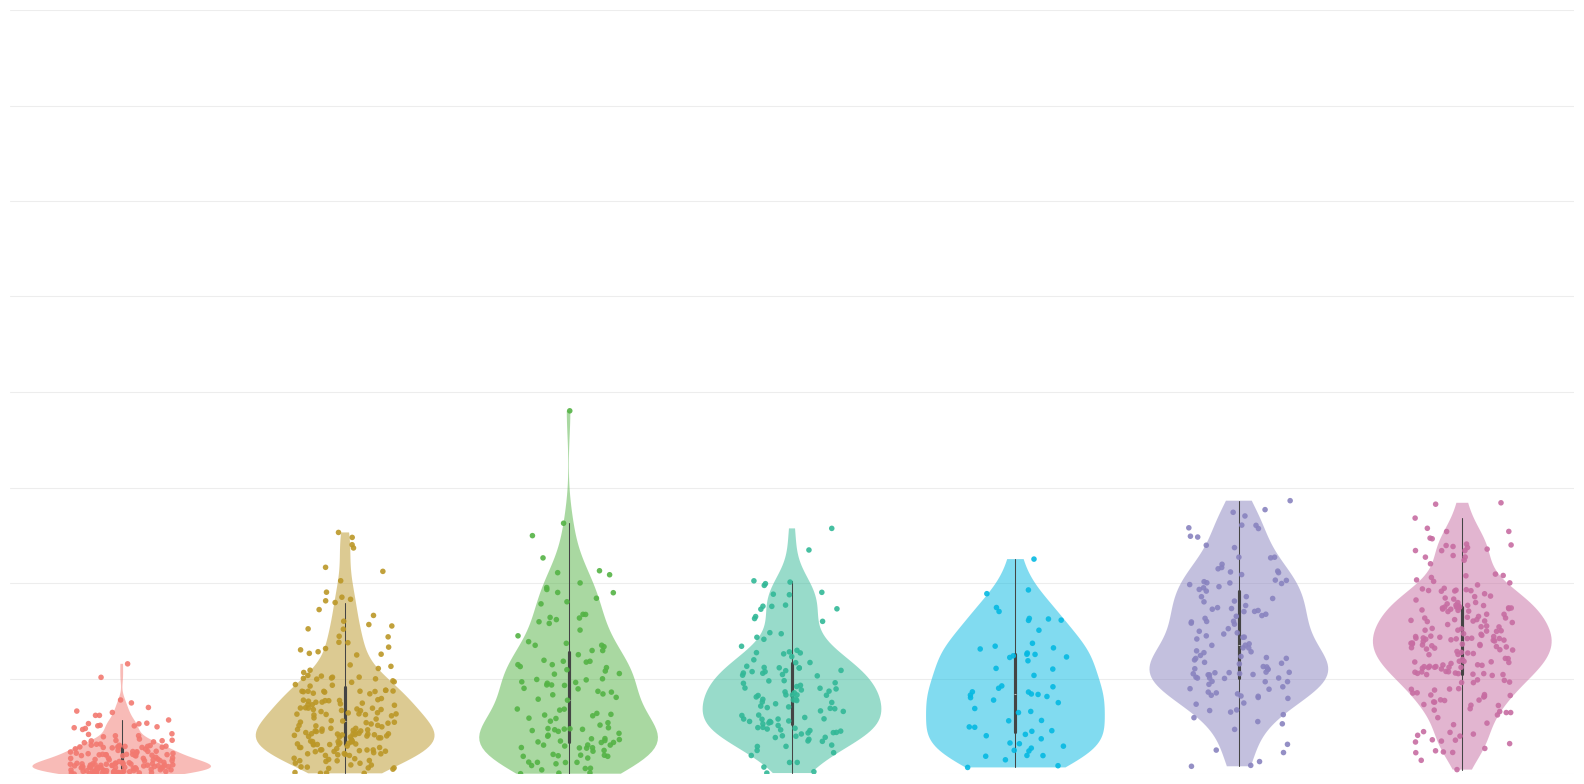

In [71]:
from matplotlib.ticker import PercentFormatter

COLOR_PALETTE = {
    "Vis": "#F27970",
    "SomMot": "#BB9727",
    "DorsAttn": "#54B345",
    "SalVentAttn": "#32B897",
    "Limbic": "#05B9E2",
    "Cont": "#8983BF",
    "Default": "#C76DA2",
}


def plot_network_selectivity_violinplot(parcel_network_df, network_summary, network_order, run, out_file=None):
    plot_df = parcel_network_df.copy()
    summary_df = network_summary.copy()

    plot_df["network"] = pd.Categorical(plot_df["network"], categories=network_order, ordered=True)
    summary_df["network"] = pd.Categorical(summary_df["network"], categories=network_order, ordered=True)
    summary_df = summary_df.sort_values("network")

    missing_colors = [network for network in network_order if network not in COLOR_PALETTE]
    if missing_colors:
        raise KeyError(f"COLOR_PALETTE is missing colors for networks: {missing_colors}")

    fig, ax = plt.subplots(figsize=(16, 8), facecolor="white")
    sns.violinplot(
        data=plot_df,
        x="network",
        y="modality_selectivity_pct",
        order=network_order,
        palette=COLOR_PALETTE,
        inner='box',
        cut=0,
        linewidth=0.5,
        saturation=1.0,
        ax=ax,
    )
    for collection in ax.collections:
        collection.set_alpha(0.5)
        collection.set_edgecolor("none")

    sns.stripplot(
        data=plot_df,
        x="network",
        y="modality_selectivity_pct",
        hue="network",
        order=network_order,
        hue_order=network_order,
        palette=COLOR_PALETTE,
        legend=False,
        alpha=0.9,
        jitter=0.23,
        size=4,
        linewidth=0,
        ax=ax,
    )

    x_positions = np.arange(len(network_order))
    means = summary_df.set_index("network").reindex(network_order)["mean_modality_selectivity_pct"].to_numpy()
    # for x_pos, mean_value in zip(x_positions, means):
    #     if np.isfinite(mean_value):
    #         ax.scatter(x_pos, mean_value, color="black", s=36, marker="D", zorder=6)

    ax.set_ylim(0, 40)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
    ax.set_xlabel("")
    ax.set_ylabel("")
    # ax.set_ylabel("Modality Selectivity (%)")
    # ax.set_title(
    #     f"sub-{run['subject_id']:02d} {run['backbones']} {run['readout']} network selectivity",
    #     pad=12,
    # )
    # ax.tick_params(axis="x", rotation=30)
    # for label in ax.get_xticklabels():
    #     label.set_horizontalalignment("right")
    ax.xaxis.grid(False)
    ax.yaxis.grid(True, linestyle="-", linewidth=0.8, alpha=0.35)

    ax.set_xticks([])
    ax.tick_params(axis="x", bottom=False, labelbottom=False)

    ax.tick_params(axis="y", left=False, labelleft=False)
    sns.despine(ax=ax)
    for spine in ax.spines.values():
        spine.set_visible(False)
        fig.tight_layout()

    if out_file is not None:
        fig.savefig(str(out_file), dpi=600, bbox_inches="tight", facecolor="white", transparent=False)
    return fig, ax


network_violinplot_path = FIGURE_ROOT / f"{file_label(run)}_network_modality_selectivity_violinplot.pdf"
network_selectivity_fig, network_selectivity_ax = plot_network_selectivity_violinplot(
    selectivity_network_df,
    network_selectivity_summary,
    schaefer_labels,
    run,
    out_file=network_violinplot_path,
)
print(network_violinplot_path)
plt.show()



## Atlas Plot Helpers

In [72]:
FMRI_ROOT = Path("/engram/nklab/datasets/algonauts_2025.competitors/fmri")
SUBJECT_ATLAS = {
    1: "sub-01/atlas/sub-01_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
    2: "sub-02/atlas/sub-02_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
    3: "sub-03/atlas/sub-03_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
    5: "sub-05/atlas/sub-05_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
}


def load_subject_schaefer(subject_id):
    path = FMRI_ROOT / SUBJECT_ATLAS[int(subject_id)]
    img = nib.load(path)
    data = np.asarray(img.dataobj, dtype=np.int32)
    return img, data


def parcel_values_to_img(parcel_values, subject_id):
    parcel_values = np.asarray(parcel_values, dtype=np.float32)
    if parcel_values.ndim != 1 or parcel_values.shape[0] != 1000:
        raise ValueError(f"Expected parcel_values shape [1000], got {parcel_values.shape}")

    atlas_img, atlas_data = load_subject_schaefer(subject_id)
    output_data = np.full(atlas_data.shape, np.nan, dtype=np.float32)
    for parcel_index in range(1000):
        output_data[atlas_data == (parcel_index + 1)] = parcel_values[parcel_index]

    return nib.Nifti1Image(output_data, affine=atlas_img.affine, header=atlas_img.header), output_data


def set_display_white_background(display, fig):
    for axis in display.axes.values():
        if hasattr(axis, "ax"):
            axis.ax.set_facecolor("white")
        else:
            axis.set_facecolor("white")
    fig.patch.set_facecolor("white")

    colorbar = getattr(display, "_cbar", None)
    if colorbar is not None:
        colorbar.ax.set_facecolor("white")
        colorbar.ax.tick_params(colors="black")
        colorbar.outline.set_edgecolor("black")
    return colorbar


def format_selectivity_colorbar(colorbar):
    if colorbar is None:
        return
    ticks = [0, 5, 10, 15, 20]
    colorbar.set_ticks(ticks)
    colorbar.set_ticklabels([f"{tick}%" for tick in ticks])
    colorbar.set_label("Modality Selectivity (%)", rotation=90, labelpad=16, fontsize=28, color="black")
    colorbar.ax.yaxis.set_label_position("right")
    colorbar.ax.yaxis.label.set_clip_on(False)
    colorbar.ax.tick_params(labelsize=24, colors="black")


def plot_selectivity_map(run, selectivity, out_file=None):
    values = 100.0 * np.asarray(selectivity, dtype=np.float32)
    output_img, output_data = parcel_values_to_img(values, run["subject_id"])

    vals = np.abs(output_data[np.isfinite(output_data)])
    threshold = float(np.percentile(vals, 1)) if vals.size > 0 else 0.0
    if not np.isfinite(threshold):
        threshold = 0.0

    fig = plt.figure(figsize=(12, 4), facecolor="white")
    display = plotting.plot_glass_brain(
        output_img,
        display_mode="lyrz",
        cmap="viridis",
        colorbar=False,
        plot_abs=False,
        threshold=threshold,
        symmetric_cbar=False,
        vmin=0, #selectivity.min() * 100.0,
        vmax=40,
        black_bg=False,
        figure=fig,
    )

    colorbar = set_display_white_background(display, fig)
    format_selectivity_colorbar(colorbar)

    if out_file is not None:
        fig.savefig(
            str(out_file),
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="white",
            transparent=False,
        )
    plotting.show()
    return display


## Plot Selectivity Map

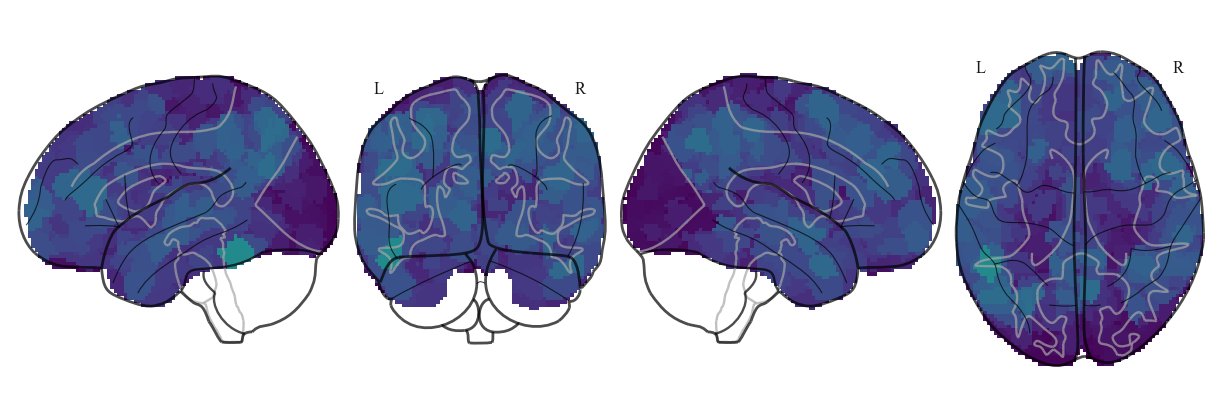

/engram/nklab/pf2477/multimodal_encoder/attn_map_analysis/tables/sub-01_videmae_wav2vec_deberta_parcels_04-18-2026-01-08_modality_selectivity_from_norm.csv
/engram/nklab/pf2477/multimodal_encoder/attn_map_analysis/figures/sub-01_videmae_wav2vec_deberta_parcels_04-18-2026-01-08_modality_selectivity_from_norm_glass.pdf


In [73]:
out_file = FIGURE_ROOT / f"{file_label(run)}_modality_selectivity_from_norm_glass.pdf"
selectivity_display = plot_selectivity_map(run, modality_selectivity, out_file=out_file)
print(csv_path)
print(out_file)


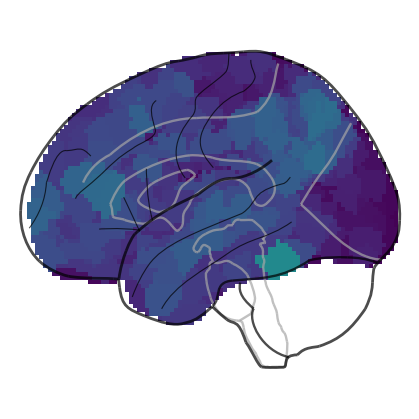

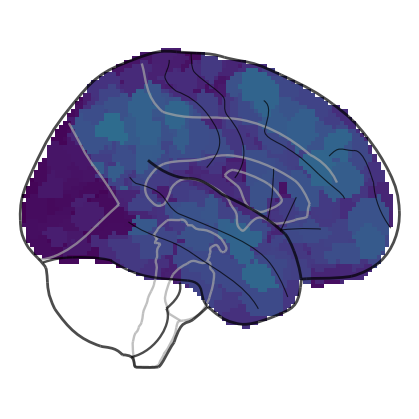

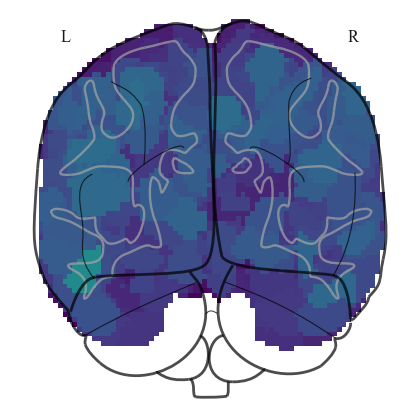

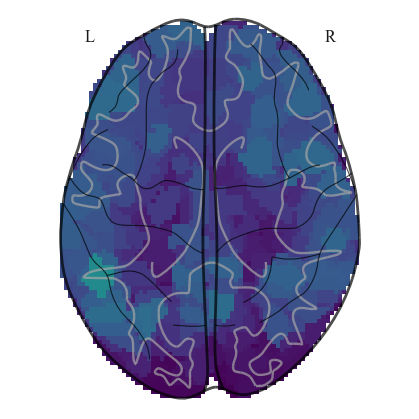

In [74]:
def plot_selectivity_map_view(run, selectivity, display_mode, out_file=None):
    values = 100.0 * np.asarray(selectivity, dtype=np.float32)
    output_img, output_data = parcel_values_to_img(values, run["subject_id"])

    vals = np.abs(output_data[np.isfinite(output_data)])
    threshold = float(np.percentile(vals, 1)) if vals.size > 0 else 0.0
    if not np.isfinite(threshold):
        threshold = 0.0

    fig = plt.figure(figsize=(4, 4), facecolor="white")
    display = plotting.plot_glass_brain(
        output_img,
        display_mode=display_mode,
        cmap="viridis",
        colorbar=False,
        plot_abs=False,
        threshold=threshold,
        symmetric_cbar=False,
        vmin=0, #selectivity.min() * 100.0,
        vmax=40,
        black_bg=False,
        figure=fig,
    )

    colorbar = set_display_white_background(display, fig)
    format_selectivity_colorbar(colorbar)

    if out_file is not None:
        fig.savefig(
            str(out_file),
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="white",
            transparent=False,
        )
    plotting.show()
    return display

for view in ["l", "r", "y", "z"]:
    selectivity_display = plot_selectivity_map_view(run, modality_selectivity, view, out_file=None)